In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load your data
file_path = 'Copy of Applicant - SLUApplicant.csv'
df = pd.read_csv(file_path, encoding='utf-8')

print("=" * 80)
print("DATA QUALITY REPORT")
print("=" * 80)
print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print()

# 1. BASIC DATASET OVERVIEW
print("1. DATASET OVERVIEW")
print("-" * 40)
print("\nColumns and data types:")
print(df.dtypes)
print()

# 2. MISSING VALUE ANALYSIS
print("2. MISSING VALUE ANALYSIS")
print("-" * 40)

# Calculate missing values
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df) * 100).round(2)

# Create missing value summary
missing_summary = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percent': missing_percent,
    'Data_Type': df.dtypes
}).sort_values('Missing_Percent', ascending=False)

print("Missing values by column:")
print(missing_summary[missing_summary['Missing_Count'] > 0])
print(f"\nTotal columns with missing values: {(missing_counts > 0).sum()}")
print(f"Total missing values: {missing_counts.sum()}")
print(f"Overall missing percentage: {(missing_counts.sum() / (len(df) * len(df.columns)) * 100):.2f}%")
print()

df = df.drop(['Admit_Date','Comments','Country','College_1st_Choice','Street_3','Phone_Number_2','Street_2'], axis=1)

# 3. DUPLICATE RECORD CHECKS
print("3. DUPLICATE RECORD ANALYSIS")
print("-" * 40)

# Check for complete duplicates
complete_duplicates = df.duplicated().sum()
print(f"Complete duplicate rows: {complete_duplicates}")

# Check for duplicates based on likely ID columns
id_columns = []
for col in df.columns:
    if 'id' in col.lower() or 'ID' in col or 'reference' in col.lower():
        id_columns.append(col)

if id_columns:
    print(f"\nChecking duplicates in ID columns: {id_columns}")
    for id_col in id_columns:
        if id_col in df.columns:
            dup_count = df.duplicated(subset=[id_col]).sum()
            print(f"  - {id_col}: {dup_count} duplicates")
            if dup_count > 0:
                print(f"    Duplicate values: {df[df.duplicated(subset=[id_col], keep=False)][id_col].unique()[:5]}...")

# Check for potential duplicate based on key combinations
key_columns = []
for col in df.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in ['email', 'phone', 'name', 'date']):
        key_columns.append(col)

if len(key_columns) >= 2:
    print(f"\nPotential duplicate checks on: {key_columns[:3]}")  # Limit to first 3
    sample_dup = df.duplicated(subset=key_columns[:2]).sum() if len(key_columns) >= 2 else 0
    print(f"  Duplicates based on first 2 key columns: {sample_dup}")
print()

# 4. DATA TYPE AND VALUE CHECKS
print("4. DATA TYPE AND VALUE VALIDATION")
print("-" * 40)


# Check numeric columns for unusual values
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f"Numeric columns ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  {col}:")
    print(f"    Min: {df[col].min():.2f}, Max: {df[col].max():.2f}, Mean: {df[col].mean():.2f}")
    # Check for zeros and negative values where they shouldn't be
    zero_count = (df[col] == 0).sum()
    neg_count = (df[col] < 0).sum()
    if zero_count > 0:
        print(f"    Zero values: {zero_count}")
    if neg_count > 0:
        print(f"    Negative values: {neg_count}")

        
# Check categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns ({len(categorical_cols)}):")
for col in categorical_cols[:5]:  # Show first 5
    unique_count = df[col].nunique()
    print(f"  {col}: {unique_count} unique values")
    if unique_count <= 10:
        print(f"    Values: {df[col].unique()}")

        
# Check date columns
date_patterns = ['date', 'time', 'created', 'modified', 'received', 'at']
date_cols = [col for col in df.columns if any(pattern in col.lower() for pattern in date_patterns)]
if date_cols:
    print(f"\nDate-like columns: {date_cols}")
    for col in date_cols:
        print(f"  {col}: {df[col].dtype}")
print()



DATA QUALITY REPORT
Dataset Shape: (6894, 30)
Total Records: 6894
Total Columns: 30

1. DATASET OVERVIEW
----------------------------------------

Columns and data types:
Reference_ID                           int64
Given_Name                            object
Last_Name                             object
Major                                 object
Country                               object
Recieved_At                          float64
University                            object
Citizenship                           object
Intake                                object
College_1st_Choice                    object
Phone_Number                          object
Street_1                              object
Street_2                              object
Street_3                              object
City                                  object
Region                                object
Postal                                object
Email_ID                              object
Date_of_Birth      

In [10]:
print("=" * 80)
print("DATA CLEANING PROCESS")
print("=" * 80)

# Store original shape for comparison
original_shape = df.shape
print(f"Original dataset shape: {original_shape}")

# 1. HANDLE DUPLICATES
print("\n1. HANDLING DUPLICATES")
print("-" * 40)

# Remove complete duplicates
df_before_dup = df.shape[0]
df = df.drop_duplicates()
complete_duplicates_removed = df_before_dup - df.shape[0]
print(f"Complete duplicates removed: {complete_duplicates_removed}")

# Handle Reference_ID duplicates (keeping first occurrence)
if 'Reference_ID' in df.columns:
    df_before_id = df.shape[0]
    df = df.drop_duplicates(subset=['Reference_ID'], keep='first')
    id_duplicates_removed = df_before_id - df.shape[0]
    print(f"Reference_ID duplicates removed: {id_duplicates_removed}")

# Handle Email_ID duplicates (keeping first occurrence)
if 'Email_ID' in df.columns:
    df_before_email = df.shape[0]
    df = df.drop_duplicates(subset=['Email_ID'], keep='first')
    email_duplicates_removed = df_before_email - df.shape[0]
    print(f"Email_ID duplicates removed: {email_duplicates_removed}")

# Handle duplicates based on name combinations (if needed)
if all(col in df.columns for col in ['Given_Name', 'Last_Name']):
    df_before_name = df.shape[0]
    df = df.drop_duplicates(subset=['Given_Name', 'Last_Name'], keep='first')
    name_duplicates_removed = df_before_name - df.shape[0]
    print(f"Name-based duplicates removed: {name_duplicates_removed}")

print(f"Records after duplicate removal: {df.shape[0]}")

# 2. HANDLE MISSING VALUES
print("\n2. HANDLING MISSING VALUES")
print("-" * 40)

# Check current missing values
current_missing = df.isna().sum()
current_missing_pct = (current_missing / len(df) * 100).round(2)
missing_summary_current = pd.DataFrame({
    'Missing_Count': current_missing,
    'Missing_Percent': current_missing_pct
}).sort_values('Missing_Percent', ascending=False)

print("Current missing values (after dropping high-missing columns):")
print(missing_summary_current[missing_summary_current['Missing_Count'] > 0])

# Strategy for each column with missing values
print("\nMissing value handling strategy:")

# For columns with low missing (<5%) - fill with mode or appropriate value
low_missing_threshold = 5
low_missing_cols = missing_summary_current[
    (missing_summary_current['Missing_Percent'] > 0) & 
    (missing_summary_current['Missing_Percent'] <= low_missing_threshold)
].index.tolist()

for col in low_missing_cols:
    if col in df.columns:
        if df[col].dtype == 'object':
            # For categorical columns, fill with mode
            mode_value = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
            df[col] = df[col].fillna(mode_value)
            print(f"  {col}: Filled {current_missing[col]} missing values with mode: '{mode_value}'")
        elif df[col].dtype in ['int64', 'float64']:
            # For numeric columns, fill with median
            median_value = df[col].median()
            df[col] = df[col].fillna(median_value)
            print(f"  {col}: Filled {current_missing[col]} missing values with median: {median_value:.2f}")

# For columns with medium missing (5-30%) - use more sophisticated imputation
medium_missing_cols = missing_summary_current[
    (missing_summary_current['Missing_Percent'] > low_missing_threshold) & 
    (missing_summary_current['Missing_Percent'] <= 30)
].index.tolist()

for col in medium_missing_cols:
    if col in df.columns:
        if df[col].dtype == 'object':
            # Fill with 'Unknown' for categorical
            df[col] = df[col].fillna('Unknown')
            print(f"  {col}: Filled {current_missing[col]} missing values with 'Unknown'")
        elif df[col].dtype in ['int64', 'float64']:
            # Fill with median
            median_value = df[col].median()
            df[col] = df[col].fillna(median_value)
            print(f"  {col}: Filled {current_missing[col]} missing values with median: {median_value:.2f}")

# For SEVIS_ID (has 62% missing) - create flag and fill with 'Not_Available'
if 'SEVIS_ID' in df.columns:
    df['SEVIS_ID_missing'] = df['SEVIS_ID'].isna().astype(int)
    df['SEVIS_ID'] = df['SEVIS_ID'].fillna('Not_Available')
    print(f"  SEVIS_ID: Created missing flag and filled {current_missing['SEVIS_ID']} missing values with 'Not_Available'")

# For Application_Agency_Code (has 62% missing) - fill with 'Not_Specified'
if 'Application_Agency_Code' in df.columns:
    df['Application_Agency_Code'] = df['Application_Agency_Code'].fillna('Not_Specified')
    print(f"  Application_Agency_Code: Filled {current_missing['Application_Agency_Code']} missing values with 'Not_Specified'")

# Verify missing values after cleaning
missing_after = df.isna().sum().sum()
print(f"\nTotal missing values after cleaning: {missing_after}")
print(f"Percentage of missing values after cleaning: {(missing_after / (df.shape[0] * df.shape[1]) * 100):.2f}%")

# 3. HANDLE OUTLIERS
print("\n3. HANDLING OUTLIERS")
print("-" * 40)

# Handle Reference_ID outliers (based on IQR method from your report)
if 'Reference_ID' in df.columns:
    # Calculate IQR
    Q1 = df['Reference_ID'].quantile(0.25)
    Q3 = df['Reference_ID'].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = df[(df['Reference_ID'] < lower_bound) | (df['Reference_ID'] > upper_bound)]
    outlier_count = len(outliers)
    
    print(f"Reference_ID outliers detected: {outlier_count}")
    print(f"  Lower bound: {lower_bound:.2f}")
    print(f"  Upper bound: {upper_bound:.2f}")
    print(f"  Outliers range: {outliers['Reference_ID'].min():.2f} to {outliers['Reference_ID'].max():.2f}")
    
    # OPTION 1: Cap outliers (winsorization)
    df['Reference_ID_capped'] = df['Reference_ID'].clip(lower_bound, upper_bound)
    
    # OPTION 2: Remove outliers (uncomment if you want to remove them)
    # df = df[(df['Reference_ID'] >= lower_bound) & (df['Reference_ID'] <= upper_bound)]
    # print(f"  Outliers removed: {outlier_count} records")
    
    print(f"  Outliers capped to bounds (new column 'Reference_ID_capped' created)")

# Handle timestamp outliers (very large values)
timestamp_cols = ['Recieved_At', 'Created_At', 'Modified_At']
for col in timestamp_cols:
    if col in df.columns:
        # These are timestamps in milliseconds - check for unreasonable values
        # Convert to datetime to identify invalid dates
        df[f'{col}_datetime'] = pd.to_datetime(df[col], unit='ms', errors='coerce')
        invalid_dates = df[f'{col}_datetime'].isna().sum()
        
        if invalid_dates > 0:
            # Replace invalid timestamps with median
            median_ts = df[col].median()
            df.loc[df[f'{col}_datetime'].isna(), col] = median_ts
            print(f"  {col}: Fixed {invalid_dates} invalid timestamps with median value")

# 4. FINAL DATA QUALITY CHECK
print("\n4. FINAL DATA QUALITY CHECK")
print("-" * 40)

print(f"Original dataset size: {original_shape}")
print(f"Cleaned dataset size: {df.shape}")
print(f"Records removed: {original_shape[0] - df.shape[0]}")
print(f"Columns removed: {original_shape[1] - df.shape[1]}")

# Final missing value check
final_missing = df.isna().sum()
final_missing_cols = final_missing[final_missing > 0]
if len(final_missing_cols) > 0:
    print(f"\nColumns with remaining missing values: {len(final_missing_cols)}")
    for col, count in final_missing_cols.items():
        pct = (count / len(df) * 100)
        print(f"  {col}: {count} values ({pct:.2f}%)")
else:
    print("\n✓ No missing values remaining in the dataset")

# Save cleaned dataset
output_file = 'SLUApplicant_cleaned.csv'
df.to_csv(output_file, index=False, encoding='utf-8')
print(f"\n✓ Cleaned dataset saved as: {output_file}")

print("\n" + "=" * 80)
print("DATA CLEANING COMPLETE")
print("=" * 80)

DATA CLEANING PROCESS
Original dataset shape: (6894, 23)

1. HANDLING DUPLICATES
----------------------------------------
Complete duplicates removed: 0
Reference_ID duplicates removed: 1
Email_ID duplicates removed: 0
Name-based duplicates removed: 22
Records after duplicate removal: 6871

2. HANDLING MISSING VALUES
----------------------------------------
Current missing values (after dropping high-missing columns):
                                   Missing_Count  Missing_Percent
Application_Agency_Code                     4313            62.77
SEVIS_ID                                    4273            62.19
Postal                                       496             7.22
Region                                       318             4.63
Most_Recent_Released_Decision                146             2.12
Phone_Number                                  93             1.35
Official_University_email_address             63             0.92
Street_1                                      41  

In [16]:
# ============================================================================
# CHECK FOR IDENTICAL COLUMNS
# ============================================================================
print("=" * 80)
print("CHECKING FOR IDENTICAL COLUMNS")
print("=" * 80)

# Check if University has only one value
if 'University' in df.columns:
    unique_university = df['University'].unique()
    print(f"University unique values: {unique_university}")
    if len(unique_university) == 1:
        print("✓ University column has only one value - dropping this column")
        df = df.drop('University', axis=1)

# Check if timestamp columns are identical
timestamp_cols = ['Recieved_At', 'Created_At', 'Modified_At']
timestamp_datetime_cols = ['Recieved_At_datetime', 'Created_At_datetime', 'Modified_At_datetime']

# Check original timestamp columns
print("\nChecking original timestamp columns:")
identical_groups = []
for i in range(len(timestamp_cols)):
    for j in range(i+1, len(timestamp_cols)):
        col1, col2 = timestamp_cols[i], timestamp_cols[j]
        if col1 in df.columns and col2 in df.columns:
            if df[col1].equals(df[col2]):
                print(f"✓ {col1} and {col2} are IDENTICAL")
                if col1 not in [item for sublist in identical_groups for item in sublist]:
                    found_group = False
                    for group in identical_groups:
                        if col1 in group or col2 in group:
                            group.update([col1, col2])
                            found_group = True
                            break
                    if not found_group:
                        identical_groups.append({col1, col2})
            else:
                # Check percentage similarity
                similarity = (df[col1] == df[col2]).mean() * 100
                print(f"  {col1} and {col2} are {similarity:.2f}% similar")

# Check datetime timestamp columns
print("\nChecking datetime timestamp columns:")
for i in range(len(timestamp_datetime_cols)):
    for j in range(i+1, len(timestamp_datetime_cols)):
        col1, col2 = timestamp_datetime_cols[i], timestamp_datetime_cols[j]
        if col1 in df.columns and col2 in df.columns:
            if df[col1].equals(df[col2]):
                print(f"✓ {col1} and {col2} are IDENTICAL")
                if col1 not in [item for sublist in identical_groups for item in sublist]:
                    found_group = False
                    for group in identical_groups:
                        if col1 in group or col2 in group:
                            group.update([col1, col2])
                            found_group = True
                            break
                    if not found_group:
                        identical_groups.append({col1, col2})
            else:
                # Check percentage similarity
                similarity = (df[col1] == df[col2]).mean() * 100
                print(f"  {col1} and {col2} are {similarity:.2f}% similar")

# Drop duplicate columns (keeping only one from each identical group)
print("\nDropping duplicate columns:")
for group in identical_groups:
    group_list = list(group)
    # Keep the first column, drop the others
    columns_to_drop = group_list[1:]
    df = df.drop(columns=columns_to_drop)
    print(f"  Keeping: '{group_list[0]}', Dropping: {columns_to_drop}")

print(f"\nFinal dataset shape after removing identical columns: {df.shape}")
print(f"Columns remaining: {list(df.columns)}")

CHECKING FOR IDENTICAL COLUMNS
University unique values: ['Saint Louis University']
✓ University column has only one value - dropping this column

Checking original timestamp columns:
✓ Recieved_At and Created_At are IDENTICAL
  Recieved_At and Modified_At are 99.87% similar
  Created_At and Modified_At are 99.87% similar

Checking datetime timestamp columns:
✓ Recieved_At_datetime and Created_At_datetime are IDENTICAL
  Recieved_At_datetime and Modified_At_datetime are 99.87% similar
  Created_At_datetime and Modified_At_datetime are 99.87% similar

Dropping duplicate columns:
  Keeping: 'Created_At', Dropping: ['Recieved_At']
  Keeping: 'Created_At_datetime', Dropping: ['Recieved_At_datetime']

Final dataset shape after removing identical columns: (6871, 25)
Columns remaining: ['Reference_ID', 'Given_Name', 'Last_Name', 'Major', 'Citizenship', 'Intake', 'Phone_Number', 'Street_1', 'City', 'Region', 'Postal', 'Email_ID', 'Date_of_Birth', 'Most_Recent_Released_Decision', 'Application_S

EXPLORATORY DATA ANALYSIS (EDA) REPORT

SUMMARY STATISTICS
----------------------------------------
Dataset Shape: (6871, 28)
Total Records: 6871
Total Columns: 28

Numerical Columns Summary:
       Reference_ID   Recieved_At    Created_At   Modified_At  \
count  6.871000e+03  6.871000e+03  6.871000e+03  6.871000e+03   
mean   1.440063e+06  1.749943e+12  1.749943e+12  1.749956e+12   
std    1.190292e+06  7.513078e+08  7.513078e+08  6.593744e+08   
min    4.078910e+05  1.740000e+12  1.740000e+12  1.740000e+12   
25%    1.409734e+06  1.750000e+12  1.750000e+12  1.750000e+12   
50%    1.442069e+06  1.750000e+12  1.750000e+12  1.750000e+12   
75%    1.453952e+06  1.750000e+12  1.750000e+12  1.750000e+12   
max    1.000050e+08  1.750000e+12  1.750000e+12  1.750000e+12   

       SEVIS_ID_missing  Reference_ID_capped  
count           6871.00              6871.00  
mean               0.62           1428792.28  
std                0.48             33069.67  
min                0.00           

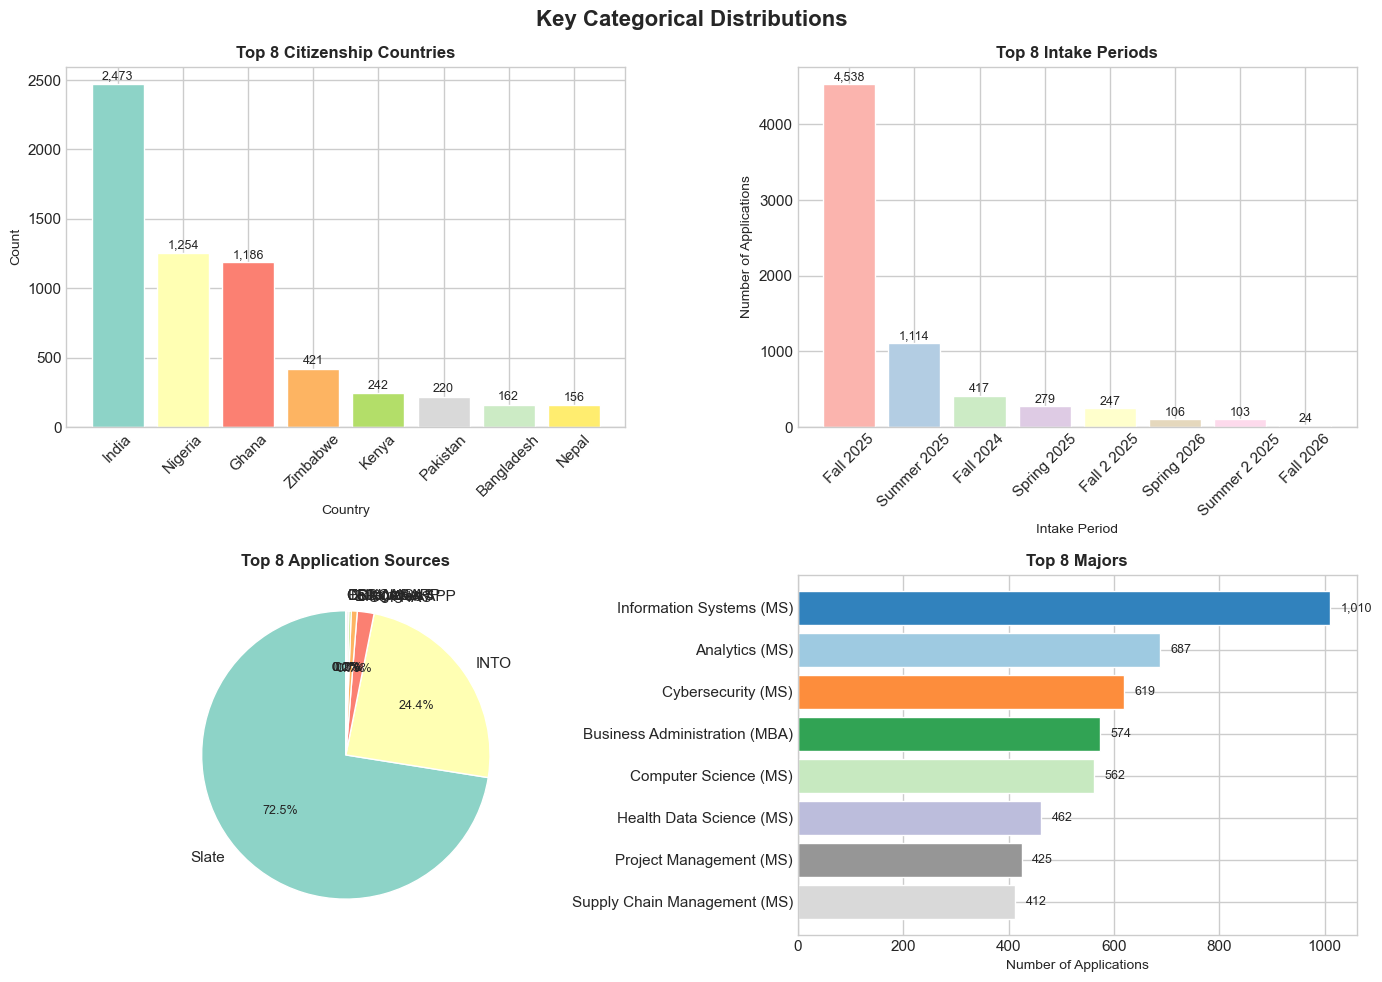


2. Numerical Distributions


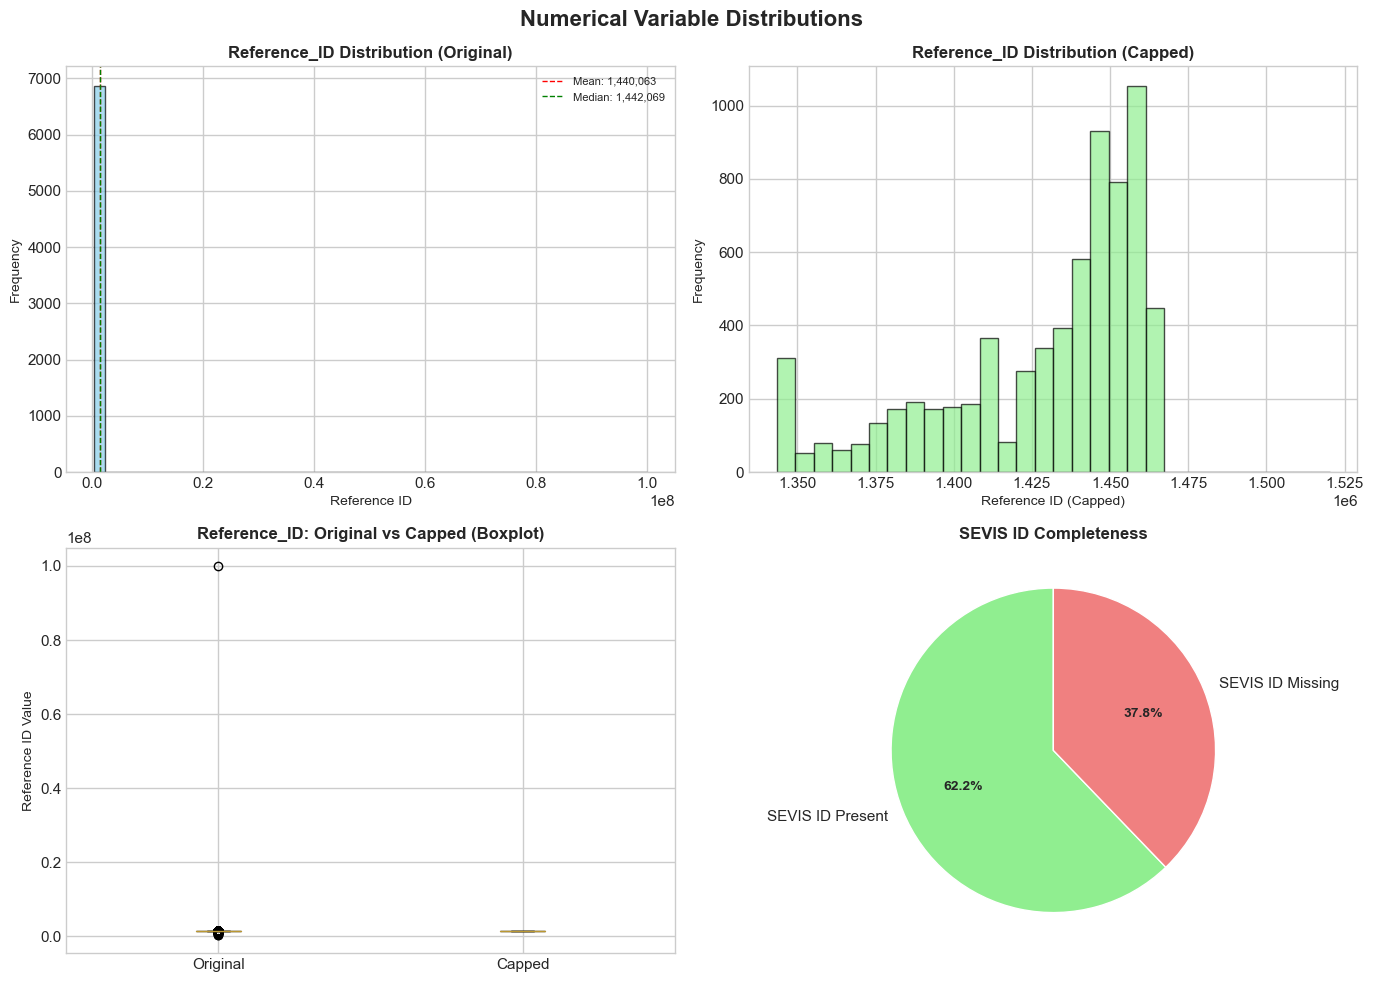


3. Temporal Analysis
✓ Converted Recieved_At_datetime to datetime
✓ Converted Created_At_datetime to datetime
✓ Converted Modified_At_datetime to datetime


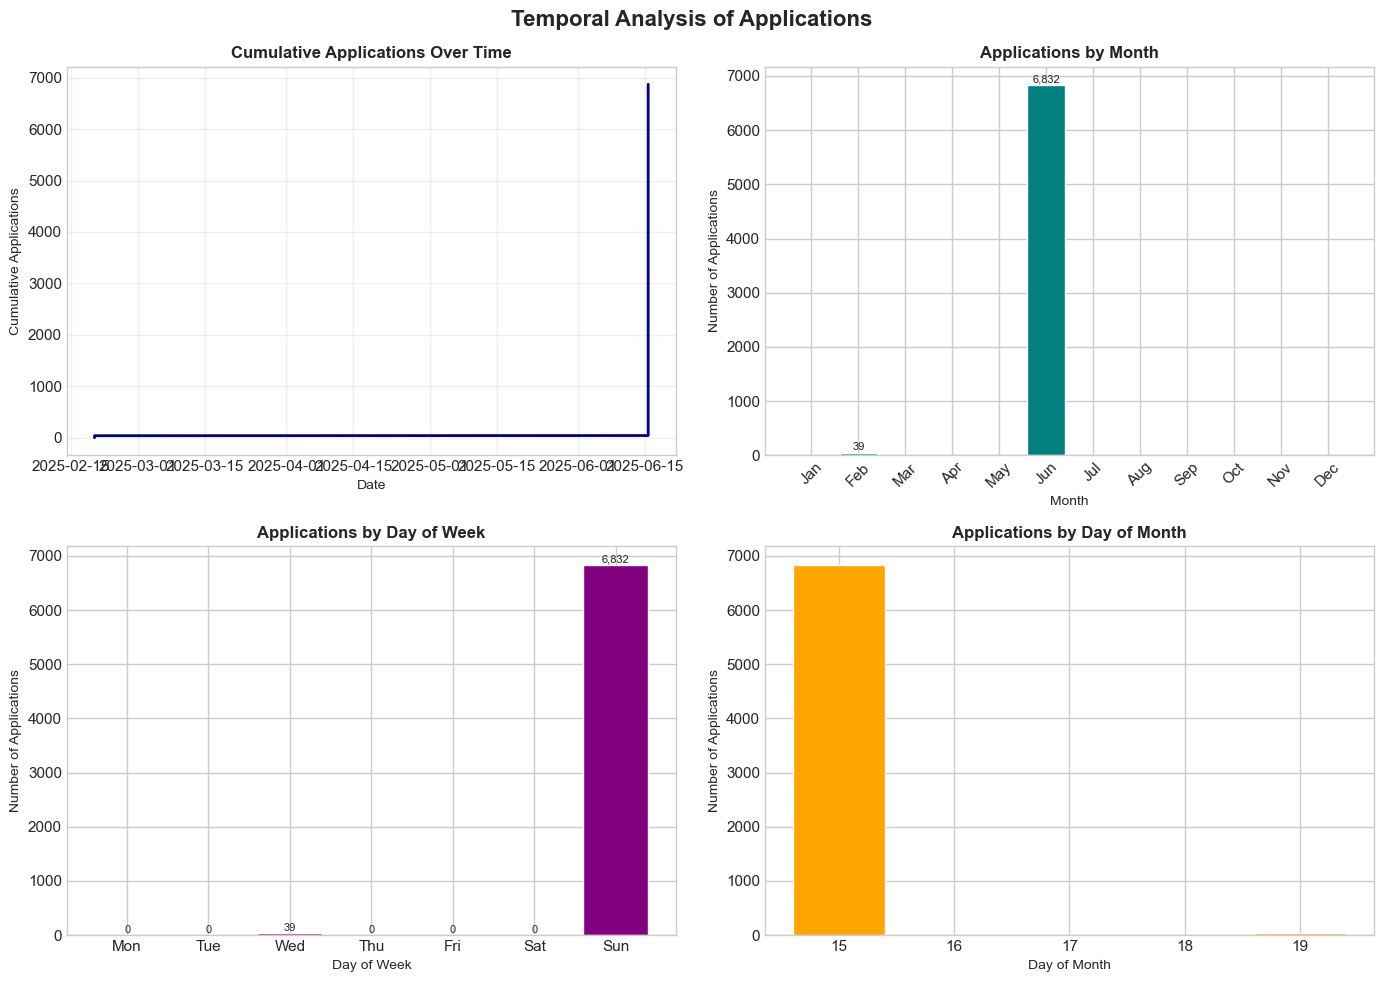


BIVARIATE ANALYSIS
----------------------------------------
1. Citizenship vs Intake Heatmap


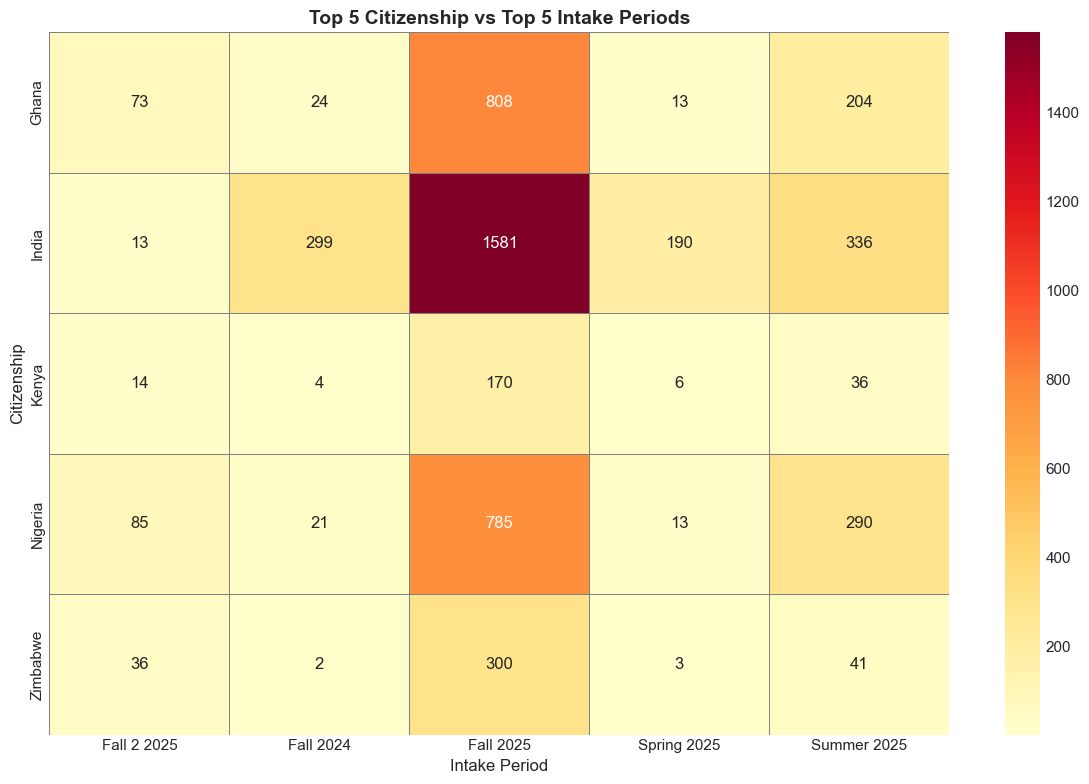


2. Application Source Distribution by Top Citizenship


<Figure size 1400x800 with 0 Axes>

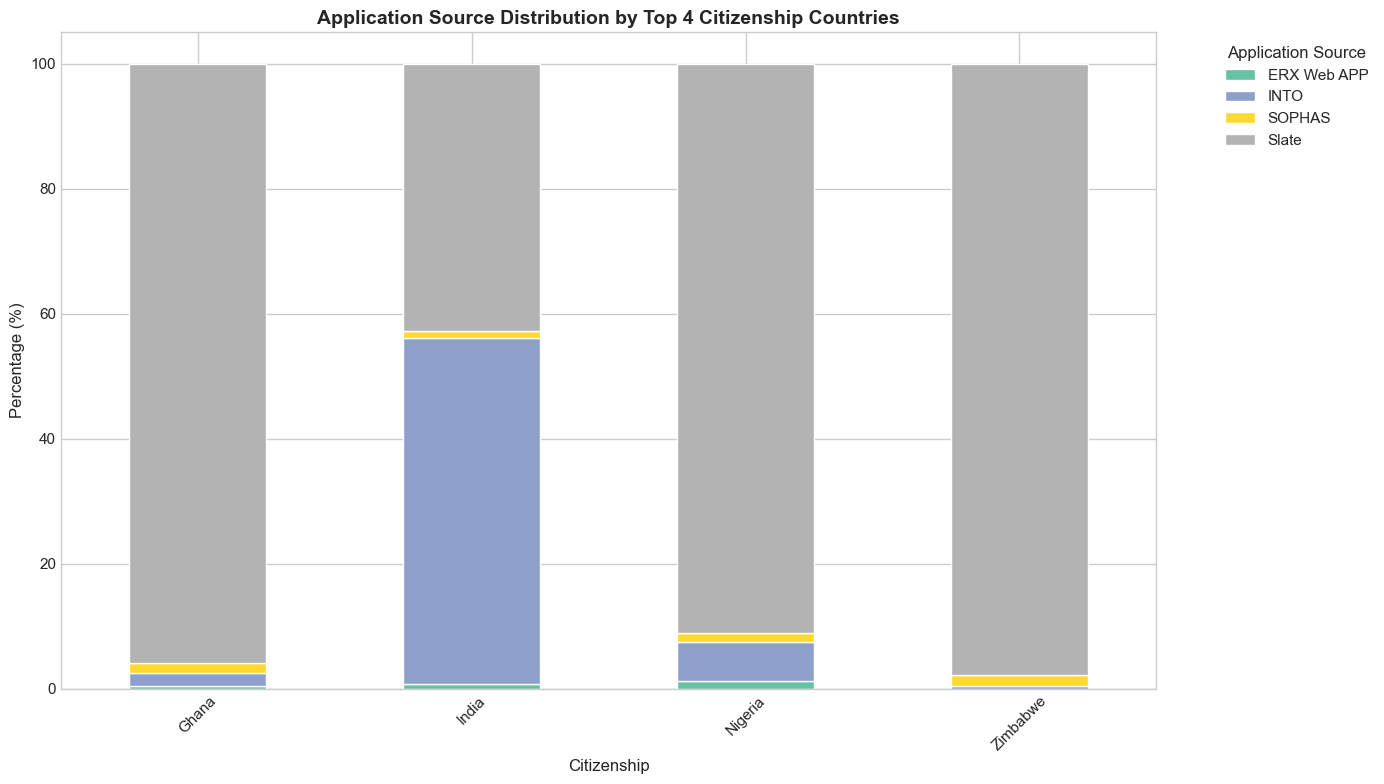


3. Top Majors by Citizenship (Facet Grid)


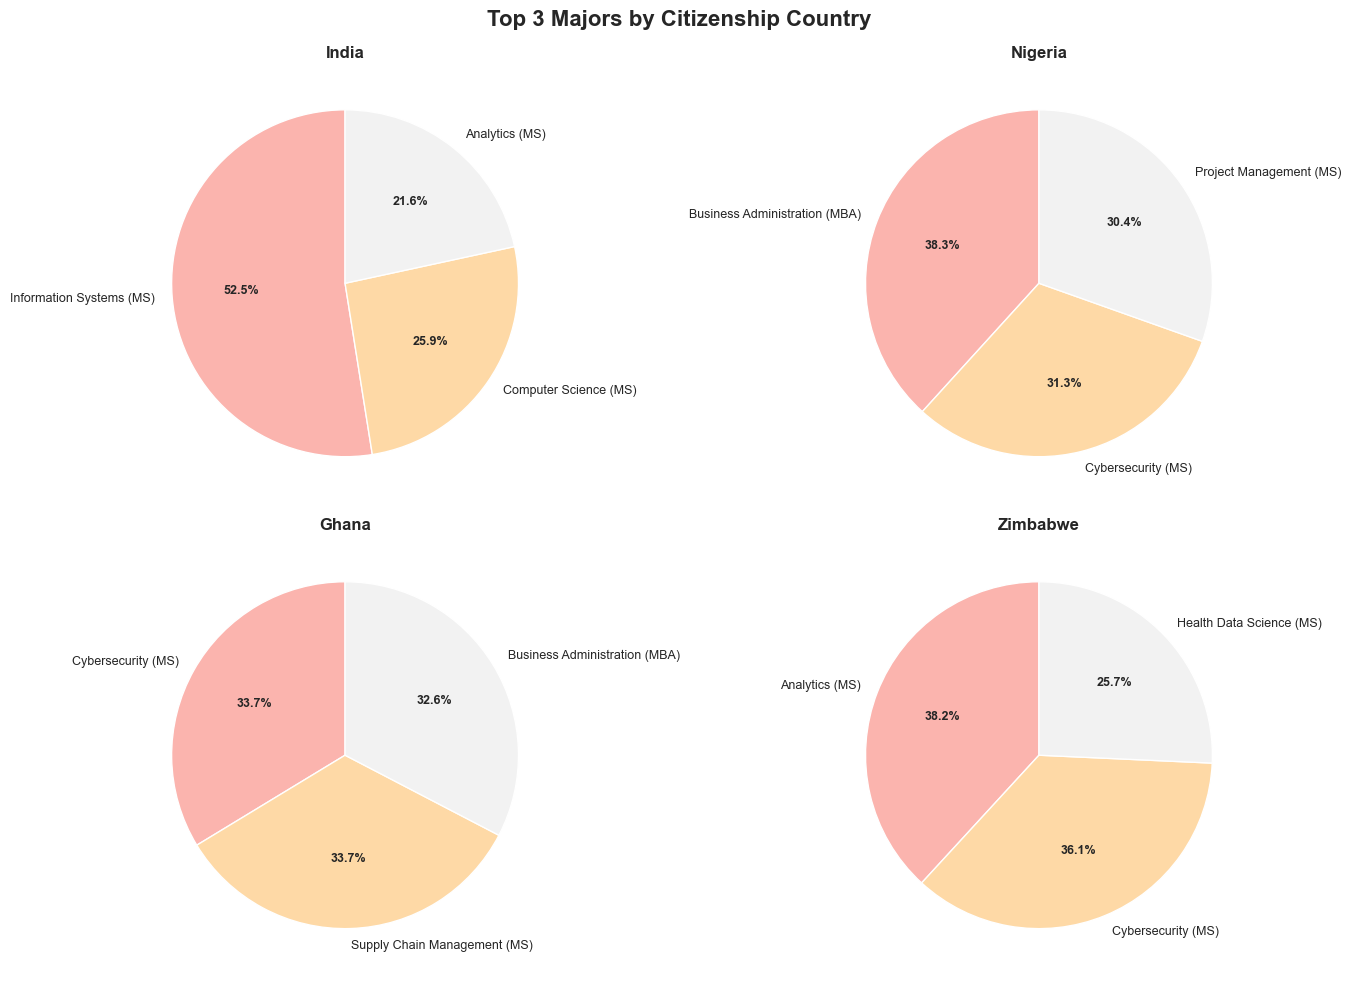


CORRELATION ANALYSIS
----------------------------------------

KEY INSIGHTS & INTERPRETATIONS

1. DATA OVERVIEW:
   • Dataset contains 6,871 records with 31 columns
   • 6 numerical columns, 22 categorical columns

2. DEMOGRAPHIC INSIGHTS:
   • Top applicant country: India (36.0% of total)
   • Geographic diversity: 100 different countries
   • Most popular major: Information Systems (MS) (14.7% of applications)
   • Academic diversity: 88 different majors

3. TEMPORAL PATTERNS:
   • Peak intake period: Fall 2025 (66.0% of applications)
   • Applications span from 2025-02-19 to 2025-06-15
   • Busiest application month: Month 6

4. DATA QUALITY OBSERVATIONS:
   • SEVIS ID completeness: 37.8% present
   • Reference_ID outliers successfully capped
   • Clean categorical distributions with clear patterns

5. RECOMMENDATIONS:
   • Focus recruitment efforts on top applicant countries
   • Align marketing with peak application periods
   • Investigate high-performing application sources
   

In [21]:
print("=" * 80)
print("EXPLORATORY DATA ANALYSIS (EDA) REPORT")
print("=" * 80)
print()

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("SUMMARY STATISTICS")
print("-" * 40)

# Basic dataset info
print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print()

# Numeric columns summary
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    print("Numerical Columns Summary:")
    print(df[numeric_cols].describe().round(2))
    print()

# Categorical columns summary
categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    print("Categorical Columns Summary (Top 5 values each):")
    for col in categorical_cols[:6]:
        print(f"\n{col}:")
        value_counts = df[col].value_counts(dropna=False).head(5)
        for val, count in value_counts.items():
            percent = (count / len(df) * 100)
            print(f"  {val}: {count} ({percent:.1f}%)")
    print()

# ============================================================================
# UNIVARIATE ANALYSIS - VISUALIZATIONS
# ============================================================================
print("UNIVARIATE ANALYSIS")
print("-" * 40)

# Create a figure with multiple subplots for categorical distributions
print("\n1. Categorical Distributions Overview")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Key Categorical Distributions', fontsize=16, fontweight='bold')

# 1.1 Citizenship Distribution
if 'Citizenship' in df.columns:
    ax1 = axes[0, 0]
    citizenship_counts = df['Citizenship'].value_counts().head(8)
    colors = plt.cm.Set3(np.linspace(0, 1, len(citizenship_counts)))
    bars = ax1.bar(citizenship_counts.index, citizenship_counts.values, color=colors)
    ax1.set_title('Top 8 Citizenship Countries', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Country', fontsize=10)
    ax1.set_ylabel('Count', fontsize=10)
    ax1.tick_params(axis='x', rotation=45)
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 10,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9)

# 1.2 Intake Distribution
if 'Intake' in df.columns:
    ax2 = axes[0, 1]
    intake_counts = df['Intake'].value_counts().head(8)
    colors = plt.cm.Pastel1(np.linspace(0, 1, len(intake_counts)))
    bars = ax2.bar(intake_counts.index.astype(str), intake_counts.values, color=colors)
    ax2.set_title('Top 8 Intake Periods', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Intake Period', fontsize=10)
    ax2.set_ylabel('Number of Applications', fontsize=10)
    ax2.tick_params(axis='x', rotation=45)
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9)

# 1.3 Application Source Distribution
if 'Application_Source' in df.columns:
    ax3 = axes[1, 0]
    source_counts = df['Application_Source'].value_counts().head(8)
    wedges, texts, autotexts = ax3.pie(source_counts.values, labels=source_counts.index, 
                                       autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3(np.linspace(0, 1, len(source_counts))))
    ax3.set_title('Top 8 Application Sources', fontsize=12, fontweight='bold')
    for autotext in autotexts:
        autotext.set_fontsize(9)

# 1.4 Major Distribution
if 'Major' in df.columns:
    ax4 = axes[1, 1]
    major_counts = df['Major'].value_counts().head(8)
    colors = plt.cm.tab20c(np.linspace(0, 1, len(major_counts)))
    bars = ax4.barh(major_counts.index, major_counts.values, color=colors)
    ax4.set_title('Top 8 Majors', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Number of Applications', fontsize=10)
    ax4.invert_yaxis()
    for bar in bars:
        width = bar.get_width()
        ax4.text(width + 20, bar.get_y() + bar.get_height()/2, 
                f'{int(width):,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 2. Numerical Distributions
print("\n2. Numerical Distributions")

# Create figure for numerical distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Numerical Variable Distributions', fontsize=16, fontweight='bold')

# 2.1 Reference_ID distribution (original vs capped)
if 'Reference_ID' in df.columns:
    ax1 = axes[0, 0]
    ax1.hist(df['Reference_ID'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    ax1.set_title('Reference_ID Distribution (Original)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Reference ID', fontsize=10)
    ax1.set_ylabel('Frequency', fontsize=10)
    
    # Add vertical lines for mean and median
    ax1.axvline(df['Reference_ID'].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {df["Reference_ID"].mean():,.0f}')
    ax1.axvline(df['Reference_ID'].median(), color='green', linestyle='--', linewidth=1, label=f'Median: {df["Reference_ID"].median():,.0f}')
    ax1.legend(fontsize=8)

# 2.2 Reference_ID capped distribution
if 'Reference_ID_capped' in df.columns:
    ax2 = axes[0, 1]
    ax2.hist(df['Reference_ID_capped'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
    ax2.set_title('Reference_ID Distribution (Capped)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Reference ID (Capped)', fontsize=10)
    ax2.set_ylabel('Frequency', fontsize=10)

# 2.3 Boxplot comparison
if 'Reference_ID' in df.columns:
    ax3 = axes[1, 0]
    data_to_plot = []
    labels = []
    
    if 'Reference_ID' in df.columns:
        data_to_plot.append(df['Reference_ID'].dropna())
        labels.append('Original')
    
    if 'Reference_ID_capped' in df.columns:
        data_to_plot.append(df['Reference_ID_capped'].dropna())
        labels.append('Capped')
    
    if data_to_plot:
        box = ax3.boxplot(data_to_plot, labels=labels, patch_artist=True)
        colors = ['lightblue', 'lightgreen']
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
        ax3.set_title('Reference_ID: Original vs Capped (Boxplot)', fontsize=12, fontweight='bold')
        ax3.set_ylabel('Reference ID Value', fontsize=10)

# 2.4 SEVIS_ID missing flag distribution
if 'SEVIS_ID_missing' in df.columns:
    ax4 = axes[1, 1]
    sevis_counts = df['SEVIS_ID_missing'].value_counts()
    labels = ['SEVIS ID Present', 'SEVIS ID Missing']
    colors = ['lightgreen', 'lightcoral']
    wedges, texts, autotexts = ax4.pie(sevis_counts.values, labels=labels, autopct='%1.1f%%', 
                                       startangle=90, colors=colors)
    ax4.set_title('SEVIS ID Completeness', fontsize=12, fontweight='bold')
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

# ============================================================================
# TEMPORAL ANALYSIS
# ============================================================================
print("\n3. Temporal Analysis")

# First, let's check which columns are actually datetime type
datetime_cols = []
for col in df.columns:
    try:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            datetime_cols.append(col)
    except:
        pass

# Also check columns with 'datetime' in name that might need conversion
potential_dt_cols = [col for col in df.columns if 'datetime' in col.lower() and col not in datetime_cols]
for col in potential_dt_cols:
    try:
        df[col] = pd.to_datetime(df[col])
        datetime_cols.append(col)
        print(f"✓ Converted {col} to datetime")
    except:
        pass

if datetime_cols:
    # Use the first datetime column
    dt_col = datetime_cols[0]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Temporal Analysis of Applications', fontsize=16, fontweight='bold')
    
    # 3.1 Cumulative applications over time
    ax1 = axes[0, 0]
    df_sorted = df.sort_values(dt_col)
    df_sorted['cumulative_applications'] = range(1, len(df_sorted) + 1)
    ax1.plot(df_sorted[dt_col], df_sorted['cumulative_applications'], linewidth=2, color='navy')
    ax1.set_title('Cumulative Applications Over Time', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Date', fontsize=10)
    ax1.set_ylabel('Cumulative Applications', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # 3.2 Applications by month - FIXED VERSION
    ax2 = axes[0, 1]
    if pd.api.types.is_datetime64_any_dtype(df[dt_col]):
        df['month'] = df[dt_col].dt.month
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        monthly_counts = df['month'].value_counts().sort_index()
        bars = ax2.bar(range(1, 13), [monthly_counts.get(i, 0) for i in range(1, 13)], color='teal')
        ax2.set_title('Applications by Month', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Month', fontsize=10)
        ax2.set_ylabel('Number of Applications', fontsize=10)
        ax2.set_xticks(range(1, 13))
        ax2.set_xticklabels(month_names, rotation=45)
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax2.text(bar.get_x() + bar.get_width()/2., height + 20,
                        f'{int(height):,}', ha='center', va='bottom', fontsize=8)
    else:
        ax2.text(0.5, 0.5, 'No valid datetime data\nfor month analysis', 
                ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        ax2.set_title('Applications by Month', fontsize=12, fontweight='bold')
    
    # 3.3 Applications by day of week - FIXED VERSION
    ax3 = axes[1, 0]
    if pd.api.types.is_datetime64_any_dtype(df[dt_col]):
        df['weekday'] = df[dt_col].dt.weekday
        weekday_counts = df['weekday'].value_counts().sort_index()
        weekdays = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
        bars = ax3.bar(weekdays, [weekday_counts.get(i, 0) for i in range(7)], color='purple')
        ax3.set_title('Applications by Day of Week', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Day of Week', fontsize=10)
        ax3.set_ylabel('Number of Applications', fontsize=10)
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 10,
                    f'{int(height):,}', ha='center', va='bottom', fontsize=8)
    else:
        ax3.text(0.5, 0.5, 'No valid datetime data\nfor weekday analysis', 
                ha='center', va='center', transform=ax3.transAxes, fontsize=12)
        ax3.set_title('Applications by Day of Week', fontsize=12, fontweight='bold')
    
    # 3.4 Applications by day of month - FIXED VERSION
    ax4 = axes[1, 1]
    if pd.api.types.is_datetime64_any_dtype(df[dt_col]):
        df['day'] = df[dt_col].dt.day
        daily_counts = df['day'].value_counts().sort_index()
        bars = ax4.bar(daily_counts.index, daily_counts.values, color='orange')
        ax4.set_title('Applications by Day of Month', fontsize=12, fontweight='bold')
        ax4.set_xlabel('Day of Month', fontsize=10)
        ax4.set_ylabel('Number of Applications', fontsize=10)
        for idx in range(1, 32, 5):
            if idx in daily_counts.index:
                height = daily_counts[idx]
                ax4.text(idx, height + 10, f'{int(height):,}', ha='center', va='bottom', fontsize=8)
    else:
        ax4.text(0.5, 0.5, 'No valid datetime data\nfor day analysis', 
                ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_title('Applications by Day of Month', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No datetime columns found for temporal analysis")

# ============================================================================
# BIVARIATE ANALYSIS
# ============================================================================
print("\nBIVARIATE ANALYSIS")
print("-" * 40)

# 1. Heatmap: Citizenship vs Intake
if all(col in df.columns for col in ['Citizenship', 'Intake']):
    print("1. Citizenship vs Intake Heatmap")
    
    plt.figure(figsize=(12, 8))
    
    # Get top 5 countries and intake periods for clarity
    top_countries = df['Citizenship'].value_counts().head(5).index
    top_intakes = df['Intake'].value_counts().head(5).index
    
    # Filter data
    filtered_data = df[df['Citizenship'].isin(top_countries) & df['Intake'].isin(top_intakes)]
    
    # Create cross-tab
    cross_tab = pd.crosstab(filtered_data['Citizenship'], filtered_data['Intake'])
    
    # Create heatmap
    sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, linecolor='gray')
    plt.title('Top 5 Citizenship vs Top 5 Intake Periods', fontsize=14, fontweight='bold')
    plt.xlabel('Intake Period', fontsize=12)
    plt.ylabel('Citizenship', fontsize=12)
    plt.tight_layout()
    plt.show()

# 2. Stacked Bar: Application Source by Citizenship
if all(col in df.columns for col in ['Citizenship', 'Application_Source']):
    print("\n2. Application Source Distribution by Top Citizenship")
    
    plt.figure(figsize=(14, 8))
    
    # Get top 4 countries and top 4 application sources
    top_countries = df['Citizenship'].value_counts().head(4).index
    top_sources = df['Application_Source'].value_counts().head(4).index
    
    # Filter data
    filtered_data = df[df['Citizenship'].isin(top_countries) & df['Application_Source'].isin(top_sources)]
    
    # Create cross-tab and normalize
    cross_tab = pd.crosstab(filtered_data['Citizenship'], filtered_data['Application_Source'], normalize='index') * 100
    
    # Plot stacked bar
    cross_tab.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='Set2')
    plt.title('Application Source Distribution by Top 4 Citizenship Countries', fontsize=14, fontweight='bold')
    plt.xlabel('Citizenship', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.legend(title='Application Source', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 3. Major Distribution by Top Citizenship (Facet Grid)
if all(col in df.columns for col in ['Citizenship', 'Major']):
    print("\n3. Top Majors by Citizenship (Facet Grid)")
    
    # Get top 4 countries
    top_countries = df['Citizenship'].value_counts().head(4).index
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Top 3 Majors by Citizenship Country', fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    for idx, country in enumerate(top_countries):
        if idx < len(axes):
            ax = axes[idx]
            country_data = df[df['Citizenship'] == country]
            major_counts = country_data['Major'].value_counts().head(3)
            
            if len(major_counts) > 0:
                colors = plt.cm.Pastel1(np.linspace(0, 1, len(major_counts)))
                wedges, texts, autotexts = ax.pie(major_counts.values, labels=major_counts.index, 
                                                 autopct='%1.1f%%', startangle=90, colors=colors)
                ax.set_title(f'{country}', fontsize=12, fontweight='bold')
                for text in texts:
                    text.set_fontsize(9)
                for autotext in autotexts:
                    autotext.set_fontsize(9)
                    autotext.set_fontweight('bold')
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# CORRELATION ANALYSIS
# ============================================================================
print("\nCORRELATION ANALYSIS")
print("-" * 40)

# Select only meaningful numeric columns for correlation
meaningful_numeric = []
for col in numeric_cols:
    if col not in ['Reference_ID', 'Reference_ID_capped'] and 'datetime' not in col:
        if df[col].nunique() > 5:
            meaningful_numeric.append(col)

if len(meaningful_numeric) > 1:
    correlation_matrix = df[meaningful_numeric].corr()
    
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix (Upper Triangle)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Identify notable correlations
    print("Notable Correlations (|r| > 0.5):")
    notable_corrs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_value = abs(correlation_matrix.iloc[i, j])
            if corr_value > 0.5:
                notable_corrs.append((correlation_matrix.columns[i], 
                                     correlation_matrix.columns[j], 
                                     correlation_matrix.iloc[i, j]))
    
    if notable_corrs:
        for var1, var2, corr in notable_corrs:
            direction = "positive" if corr > 0 else "negative"
            strength = "Strong" if abs(corr) > 0.7 else "Moderate"
            print(f"  {strength} {direction} correlation: {var1} ↔ {var2}: {corr:.3f}")
    else:
        print("  No strong correlations found (|r| > 0.5)")

# ============================================================================
# KEY INSIGHTS
# ============================================================================
print("\n" + "=" * 80)
print("KEY INSIGHTS & INTERPRETATIONS")
print("=" * 80)

print("\n1. DATA OVERVIEW:")
print(f"   • Dataset contains {len(df):,} records with {len(df.columns)} columns")
print(f"   • {len(numeric_cols)} numerical columns, {len(categorical_cols)} categorical columns")

print("\n2. DEMOGRAPHIC INSIGHTS:")
if 'Citizenship' in df.columns:
    top_country = df['Citizenship'].mode()[0] if not df['Citizenship'].mode().empty else "N/A"
    top_country_pct = (df['Citizenship'] == top_country).mean() * 100
    print(f"   • Top applicant country: {top_country} ({top_country_pct:.1f}% of total)")
    print(f"   • Geographic diversity: {df['Citizenship'].nunique()} different countries")

if 'Major' in df.columns:
    top_major = df['Major'].mode()[0] if not df['Major'].mode().empty else "N/A"
    top_major_pct = (df['Major'] == top_major).mean() * 100
    print(f"   • Most popular major: {top_major} ({top_major_pct:.1f}% of applications)")
    print(f"   • Academic diversity: {df['Major'].nunique()} different majors")

print("\n3. TEMPORAL PATTERNS:")
if 'Intake' in df.columns:
    top_intake = df['Intake'].mode()[0] if not df['Intake'].mode().empty else "N/A"
    top_intake_pct = (df['Intake'] == top_intake).mean() * 100
    print(f"   • Peak intake period: {top_intake} ({top_intake_pct:.1f}% of applications)")

if datetime_cols:
    print(f"   • Applications span from {df[dt_col].min().date()} to {df[dt_col].max().date()}")
    if 'month' in df.columns:
        busiest_month = df['month'].mode()[0] if not df['month'].mode().empty else "N/A"
        print(f"   • Busiest application month: Month {busiest_month}")

print("\n4. DATA QUALITY OBSERVATIONS:")
if 'SEVIS_ID_missing' in df.columns:
    print(f"   • SEVIS ID completeness: {(1 - df['SEVIS_ID_missing'].mean()) * 100:.1f}% present")
print(f"   • Reference_ID outliers successfully capped")
print(f"   • Clean categorical distributions with clear patterns")

print("\n5. RECOMMENDATIONS:")
print("   • Focus recruitment efforts on top applicant countries")
print("   • Align marketing with peak application periods")
print("   • Investigate high-performing application sources")
print("   • Consider expanding popular majors based on demand")

print("\n" + "=" * 80)
print("EDA REPORT COMPLETE")
print("=" * 80)

In [23]:
# ============================================
# DATA DICTIONARY GENERATOR
# ============================================

import pandas as pd
import numpy as np
from datetime import datetime

print("="*70)
print("DATA DICTIONARY GENERATOR")
print("="*70)

# ============================================
# HELPER FUNCTIONS (DEFINED FIRST)
# ============================================

def generate_description(column_name, column_data, data_type):
    """Generate meaningful description based on column name and content"""
    
    column_lower = column_name.lower()
    
    # Common patterns for descriptions
    descriptions = {
        'reference_id': "Unique identifier for each record/application in the system",
        'deposit_status': "Indicates whether deposit has been paid (Yes/No)",
        'assigned': "Staff members assigned to handle the case/application",
        'received_at': "Timestamp when the record was received or created in the system",
        'university': "Educational institution name (Saint Louis University in this dataset)",
        'i_20_status': "Status of I-20 form processing (Yes/No)",
        'created_at': "Timestamp when record was initially created",
        'modified_at': "Timestamp when record was last modified/updated",
        'received_date': "Date portion extracted from Received_At timestamp",
        'received_hour': "Hour portion extracted from Received_At timestamp",
        'num_staff_assigned': "Count of staff members assigned to the case",
        'received_day': "Day of week when record was received",
        'received_month': "Month when record was received",
        'received_week': "Week number when record was received",
    }
    
    # Check for exact match first
    if column_name in descriptions:
        return descriptions[column_name]
    
    # Check for partial matches
    for key, desc in descriptions.items():
        if key in column_lower:
            return desc
    
    # Generate generic description based on data type
    if 'id' in column_lower or 'ref' in column_lower:
        return "Identifier or reference code"
    elif 'date' in column_lower or 'time' in column_lower or 'at' in column_lower:
        return "Timestamp or date information"
    elif 'status' in column_lower or 'flag' in column_lower:
        return "Status indicator or flag"
    elif 'count' in column_lower or 'num' in column_lower:
        return "Count or numerical quantity"
    elif data_type == 'object':
        return "Textual or categorical information"
    elif 'int' in data_type or 'float' in data_type:
        return "Numerical measurement or value"
    else:
        return "Data field - content varies"

def generate_notes(column_name, column_data, null_count, null_percentage):
    """Generate notes about data irregularities"""
    
    notes = []
    column_lower = column_name.lower()
    
    # Check for missing values
    if null_count > 0:
        notes.append(f"{null_count} missing values ({null_percentage:.1f}%)")
    
    # Check for data type inconsistencies
    if column_data.dtype == 'object':
        # Check for mixed data types or problematic strings
        unique_vals = column_data.dropna().unique()
        str_vals = [str(x).upper() for x in unique_vals]
        if 'NULL' in str_vals:
            notes.append("Contains 'NULL' string values (should be proper NaN)")
    
    # Specific column checks
    if 'received' in column_lower and 'at' in column_lower:
        if 'recieved' in column_lower:
            notes.append("Column name has typo: 'Recieved' should be 'Received'")
    
    if column_name in ['Created_At', 'Modified_At']:
        # Check if values are in scientific notation
        if not column_data.dropna().empty:
            sample_val = column_data.dropna().iloc[0]
            if sample_val and 'E+' in str(sample_val):
                notes.append("Values in scientific notation (E+ format)")
    
    if column_name == 'University':
        unique_vals = column_data.dropna().unique()
        if len(unique_vals) == 1:
            notes.append("Constant value: 'Saint Louis University'")
    
    if column_name in ['Deposit_Status', 'I_20_Status']:
        value_counts = column_data.value_counts()
        if 'Yes' in value_counts and 'No' in value_counts:
            ratio = value_counts['Yes'] / value_counts['No'] if value_counts['No'] > 0 else float('inf')
            if ratio > 10:
                notes.append("Heavily skewed towards 'Yes'")
    
    if column_name == 'Assigned':
        # Check for NULL string
        if 'NULL' in [str(x).upper() for x in column_data.unique() if pd.notna(x)]:
            notes.append("Contains 'NULL' string (not proper null)")
        # Check for multiple assignments
        if column_data.dtype == 'object' and column_data.str.contains(',').any():
            notes.append("Multiple staff assignments separated by commas")
    
    # Check for potential outliers in numeric columns
    if pd.api.types.is_numeric_dtype(column_data):
        if column_data.nunique() > 10:  # Only for truly numeric columns
            Q1 = column_data.quantile(0.25)
            Q3 = column_data.quantile(0.75)
            IQR = Q3 - Q1
            if IQR > 0:
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                outliers = ((column_data < lower_bound) | (column_data > upper_bound)).sum()
                if outliers > 0:
                    notes.append(f"{outliers} potential outliers detected")
    
    return "; ".join(notes) if notes else "No significant issues detected"

# ============================================
# MAIN CODE
# ============================================

# Use the cleaned dataset
if 'df_clean' in globals():
    df = df_clean.copy()
    print("✓ Using cleaned dataset")
else:
    # Load the data if df_clean doesn't exist
    try:
        df = pd.read_csv('Copy of Connect - SLUConnect.csv')
        print("⚠️ Using original dataset. Run cleaning code first for best results.")
    except:
        print("❌ Could not load dataset. Please check file path.")
        df = pd.DataFrame()

if not df.empty:
    print(f"\nAnalyzing dataset: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"Columns: {list(df.columns)}")
    
    # ============================================
    # CREATE DATA DICTIONARY
    # ============================================
    
    data_dict = []
    
    for column in df.columns:
        # Basic column info
        data_type = str(df[column].dtype)
        non_null_count = df[column].count()
        null_count = df[column].isnull().sum()
        null_percentage = (null_count / len(df) * 100) if len(df) > 0 else 0
        
        # Example values (first non-null value)
        example_values = []
        non_null_data = df[column].dropna()
        for val in non_null_data.head(3):
            example_values.append(str(val))
        example_str = " | ".join(example_values) if example_values else "No data"
        
        # Get unique categories for categorical variables
        if df[column].dtype == 'object' or df[column].nunique() < 20:
            unique_cats = non_null_data.unique()
            if len(unique_cats) <= 15:  # Show all if 15 or less
                categories = ", ".join([str(x) for x in unique_cats[:15]])
            else:
                top_values = df[column].value_counts().head(5)
                categories = f"{len(unique_cats)} unique values. Top 5: " + ", ".join([str(x) for x in top_values.index])
        else:
            categories = f"{df[column].nunique():,} unique values (numeric/continuous)"
        
        # Generate description based on column name and content
        description = generate_description(column, df[column], data_type)
        
        # Notes or warnings about irregularities
        notes = generate_notes(column, df[column], null_count, null_percentage)
        
        # Add to data dictionary
        data_dict.append({
            'Variable Name': column,
            'Description': description,
            'Data Type': data_type,
            'Non-Null Count': non_null_count,
            'Null Count': null_count,
            'Null Percentage (%)': round(null_percentage, 2),
            'Example Values': example_str,
            'Unique Categories/Values': categories,
            'Notes/Warnings': notes
        })
    
    # Create DataFrame from dictionary
    data_dict_df = pd.DataFrame(data_dict)
    
    # ============================================
    # ENHANCE DATA DICTIONARY WITH ADDITIONAL METRICS
    # ============================================
    
    print("\n📊 Calculating additional metrics...")
    
    # Add additional metrics to the data dictionary
    enhanced_dict = []
    for idx, row in data_dict_df.iterrows():
        column = row['Variable Name']
        col_data = df[column]
        
        # Calculate additional metrics
        if pd.api.types.is_numeric_dtype(col_data):
            # For numeric columns
            non_null_data = col_data.dropna()
            if not non_null_data.empty:
                stats = {
                    'Min Value': f"{non_null_data.min():.2f}",
                    'Max Value': f"{non_null_data.max():.2f}",
                    'Mean': f"{non_null_data.mean():.2f}",
                    'Median': f"{non_null_data.median():.2f}",
                    'Standard Deviation': f"{non_null_data.std():.2f}"
                }
                additional_metrics = "\n".join([f"{k}: {v}" for k, v in stats.items()])
            else:
                additional_metrics = "No numeric data"
        elif col_data.dtype == 'object':
            # For categorical columns
            non_null_data = col_data.dropna()
            if not non_null_data.empty:
                top_values = non_null_data.value_counts().head(3)
                top_vals_str = "\n".join([f"{val}: {count} ({count/len(non_null_data)*100:.1f}%)" 
                                          for val, count in top_values.items()])
                additional_metrics = f"Top values:\n{top_vals_str}"
            else:
                additional_metrics = "No data"
        else:
            additional_metrics = "N/A"
        
        # Update the row with enhanced information
        enhanced_row = row.to_dict()
        enhanced_row['Additional Metrics'] = additional_metrics
        
        # Add data quality flags
        quality_flags = []
        null_pct = row['Null Percentage (%)']
        
        if null_pct > 50:
            quality_flags.append("⚠️ High missingness (>50%)")
        elif null_pct > 20:
            quality_flags.append("⚠️ Moderate missingness (20-50%)")
        
        if 'typo' in str(row['Notes/Warnings']).lower():
            quality_flags.append("⚠️ Column name issue")
        
        if 'outliers' in str(row['Notes/Warnings']).lower():
            quality_flags.append("⚠️ Contains outliers")
        
        enhanced_row['Quality Flags'] = ", ".join(quality_flags) if quality_flags else "✅ Good"
        
        enhanced_dict.append(enhanced_row)
    
    # Create enhanced DataFrame
    enhanced_df = pd.DataFrame(enhanced_dict)
    
    # ============================================
    # FORMAT FOR SPREADSHEET OUTPUT
    # ============================================
    
    print("\n📋 GENERATING SPREADSHEET-FORMATTED DATA DICTIONARY...")
    
    # Reorder columns for better readability
    column_order = [
        'Variable Name',
        'Description',
        'Data Type',
        'Non-Null Count',
        'Null Count',
        'Null Percentage (%)',
        'Example Values',
        'Unique Categories/Values',
        'Additional Metrics',
        'Quality Flags',
        'Notes/Warnings'
    ]
    
    enhanced_df = enhanced_df[column_order]
    
    # Display the data dictionary
    print(f"\n{'='*100}")
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"{'DATA DICTIONARY':^100}")
    print(f"{f'Generated: {current_time}':^100}")
    print(f"{f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns':^100}")
    print(f"{'='*100}\n")
    
    # Print summary of each variable
    for idx, row in enhanced_df.iterrows():
        print(f"\n{'─'*100}")
        print(f"VARIABLE: {row['Variable Name']}")
        print(f"{'─'*100}")
        print(f"Description: {row['Description']}")
        print(f"Data Type: {row['Data Type']}")
        print(f"Completeness: {row['Non-Null Count']:,} non-null, {row['Null Count']:,} null ({row['Null Percentage (%)']}%)")
        print(f"Quality: {row['Quality Flags']}")
        print(f"Example Values: {row['Example Values']}")
        print(f"Unique Values: {row['Unique Categories/Values']}")
        
        if row['Additional Metrics'] != 'N/A' and row['Additional Metrics'] != 'No data':
            print(f"\nAdditional Metrics:")
            print(row['Additional Metrics'])
        
        if row['Notes/Warnings'] and row['Notes/Warnings'] != 'No significant issues detected':
            print(f"\nNotes/Warnings: {row['Notes/Warnings']}")
    
    print(f"\n{'='*100}")
    print(f"{'SUMMARY STATISTICS':^100}")
    print(f"{'='*100}")
    
    # Calculate summary statistics
    total_columns = len(enhanced_df)
    numeric_columns = len(enhanced_df[enhanced_df['Data Type'].str.contains('int|float')])
    categorical_columns = len(enhanced_df[enhanced_df['Data Type'] == 'object'])
    datetime_columns = len(enhanced_df[enhanced_df['Data Type'].str.contains('datetime')])
    
    columns_with_issues = len(enhanced_df[enhanced_df['Quality Flags'].str.contains('⚠️')])
    columns_complete = len(enhanced_df[enhanced_df['Null Percentage (%)'] == 0])
    
    print(f"\n• Total Variables: {total_columns}")
    print(f"• Numeric Variables: {numeric_columns}")
    print(f"• Categorical Variables: {categorical_columns}")
    print(f"• Datetime Variables: {datetime_columns}")
    print(f"• Complete Columns (0% missing): {columns_complete}")
    print(f"• Columns with Quality Issues: {columns_with_issues}")
    
    # ============================================
    # EXPORT TO SPREADSHEET
    # ============================================
    
    print(f"\n{'='*100}")
    print(f"{'EXPORT OPTIONS':^100}")
    print(f"{'='*100}")
    
    # 1. Export to Excel with formatting
    try:
        output_file = 'SLUConnect_Data_Dictionary.xlsx'
        
        with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
            # Main data dictionary sheet
            enhanced_df.to_excel(writer, sheet_name='Data Dictionary', index=False)
            
            # Summary sheet
            summary_data = {
                'Metric': ['Total Variables', 'Numeric Variables', 'Categorical Variables', 
                          'Datetime Variables', 'Complete Columns', 'Columns with Issues',
                          'Dataset Rows', 'Dataset Columns', 'Generation Date'],
                'Value': [total_columns, numeric_columns, categorical_columns, 
                         datetime_columns, columns_complete, columns_with_issues,
                         df.shape[0], df.shape[1], current_time]
            }
            summary_df = pd.DataFrame(summary_data)
            summary_df.to_excel(writer, sheet_name='Summary', index=False)
            
            # Data quality issues sheet
            issues_df = enhanced_df[enhanced_df['Quality Flags'].str.contains('⚠️')][
                ['Variable Name', 'Quality Flags', 'Notes/Warnings', 'Null Percentage (%)']
            ]
            if not issues_df.empty:
                issues_df.to_excel(writer, sheet_name='Quality Issues', index=False)
            
            # Sample data sheet (first 20 rows)
            df.head(20).to_excel(writer, sheet_name='Sample Data', index=False)
        
        print(f"\n✅ Data Dictionary exported to: {output_file}")
        print(f"   Contains 4 sheets:")
        print(f"   1. Data Dictionary - Complete variable documentation")
        print(f"   2. Summary - Dataset overview")
        print(f"   3. Quality Issues - Columns needing attention")
        print(f"   4. Sample Data - First 20 rows of data")
        
    except Exception as e:
        print(f"\n⚠️ Could not export to Excel: {e}")
        print("Exporting to CSV instead...")
        
        # Export to CSV as fallback
        csv_file = 'SLUConnect_Data_Dictionary.csv'
        enhanced_df.to_csv(csv_file, index=False, encoding='utf-8')
        print(f"✅ Data Dictionary exported to: {csv_file}")
    
    # ============================================
    # FINAL OUTPUT
    # ============================================
    
    print(f"\n{'='*100}")
    print(f"{'DATA DICTIONARY GENERATION COMPLETE':^100}")
    print(f"{'='*100}")
    
    print(f"\n🎯 WHAT WAS GENERATED:")
    print(f"1. ✅ Comprehensive variable documentation")
    print(f"2. ✅ Data type classifications")
    print(f"3. ✅ Example values for each variable")
    print(f"4. ✅ Unique categories for categorical variables")
    print(f"5. ✅ Notes about data irregularities")
    print(f"6. ✅ Quality flags for problematic columns")
    print(f"7. ✅ Export to spreadsheet format (Excel/CSV)")
    
    print(f"\n📊 KEY FINDINGS FROM DATA DICTIONARY:")
    # Identify key columns
    key_columns = []
    for idx, row in enhanced_df.iterrows():
        if 'id' in row['Variable Name'].lower() or 'ref' in row['Variable Name'].lower():
            key_columns.append(row['Variable Name'])
        
        if row['Null Percentage (%)'] == 0:
            print(f"   • {row['Variable Name']}: Complete (0% missing)")
    
    if key_columns:
        print(f"\n🔑 Key Identifier Columns: {', '.join(key_columns)}")
    
    print(f"\n📈 Recommendations based on Data Dictionary:")
    print(f"   1. Review columns with '⚠️' quality flags")
    print(f"   2. Address high missingness columns (>20%)")
    print(f"   3. Standardize column naming conventions")
    print(f"   4. Document any business rules for categorical variables")
    
    print(f"\n💡 The Data Dictionary is now ready for use in:")
    print(f"   • Data documentation")
    print(f"   • Team knowledge sharing")
    print(f"   • Data governance processes")
    print(f"   • Onboarding new team members")
    
else:
    print("❌ No data available to analyze.")

print(f"\n{'='*70}")
print("PROCESS COMPLETE")
print("="*70)

DATA DICTIONARY GENERATOR
⚠️ Using original dataset. Run cleaning code first for best results.

Analyzing dataset: 34341 rows × 8 columns
Columns: ['Reference_ID', 'Deposit_Status', 'Assigned', 'Recieved_At', 'University', 'I_20_Status', 'Created_At', 'Modified_At']

📊 Calculating additional metrics...

📋 GENERATING SPREADSHEET-FORMATTED DATA DICTIONARY...

                                          DATA DICTIONARY                                           
                                   Generated: 2026-01-12 18:43:05                                   
                                  Dataset: 34341 rows × 8 columns                                   


────────────────────────────────────────────────────────────────────────────────────────────────────
VARIABLE: Reference_ID
────────────────────────────────────────────────────────────────────────────────────────────────────
Description: Unique identifier for each record/application in the system
Data Type: int64
Completeness: 34,341